# Single-cell Analysis of Malignant NK Cell Heterogeneity (Figure 2)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure 2a–i** and related Supplementary Tables 3 for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to delineate the distinct molecular landscapes that distinguish malignant from normal NK cells. Specifically, we:
1.  Infer Copy Number Variation (CNV) profiles to segregate malignant (high-CNV) from normal (low-CNV) populations.
2.  Dissect the heterogeneity within the NK cell compartment by identifying transcriptionally distinct subclusters.
3.  Investigate the functional implications of chromosomal aberrations, viral infection status (EBV/LMP-1), and their correlation with immune checkpoint expression (CD274/PD-L1) and proliferation.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import sys
import os
mpl.rcParams['font.family'] = 'Arial'
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [723]:
figPath = "./figures/fig2"
NKPath = './data/NKTCL_NK.h5ad'
datPath = "./data/NKTCL_concat.h5ad"
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_NK = sc.read_h5ad(NKPath)
adata_concat = sc.read_h5ad(datPath)

#### **Fig. 2a** UMAP projections of NK cells colored by copy number variation (CNV) status

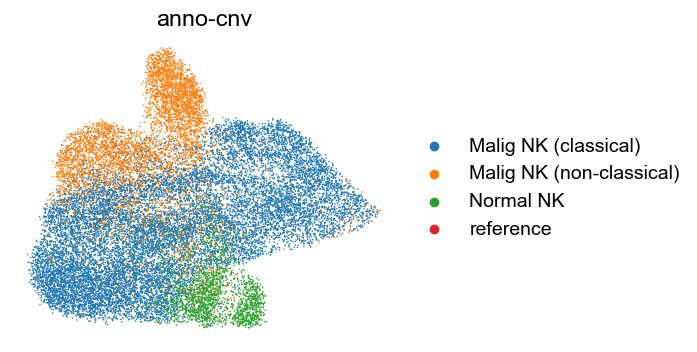

In [724]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sc.pl.umap(adata_NK, color=['anno-cnv'], size=5, ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/Fig2a.png", dpi=400, bbox_inches='tight')

#### **Fig. 2b** UMAP projections of NK cells colored by cell states.

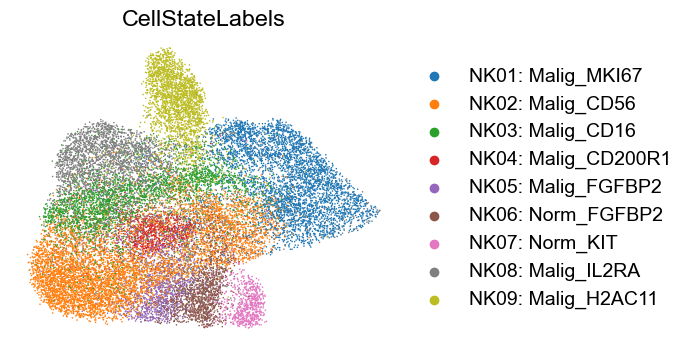

In [725]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sc.pl.umap(adata_NK, color=['CellStateLabels'], size=5, ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/Fig2b.png", dpi=400, bbox_inches='tight')

#### **Fig. 2c** Heatmap of CNVs across CNV statuses and subclusters. 
Rows represent NK cell subclusters (NK01–NK09), columns represent chromosomal regions (chr1–chr21). Color intensity reflects CNA level (red = amplification; blue = deletion).

In [ ]:
# ---------------------------------------------------------
# Load and align gene position data for CNV inference
# ---------------------------------------------------------
# This section loads gene coordinates from a reference file,
# cleans the Ensembl IDs by removing version numbers, and
# maps them to the gene symbols in the AnnData object.
# This ensures the gene list is correctly formatted for
# downstream CNV analysis.
# ---------------------------------------------------------
import infercnvpy as cnv 
import pandas as pd
chrom = pd.read_csv("./data/gene_pos.txt", sep='\t', header=None)
chrom.columns = ["symbol", "ensg", "chromosome", "start", "end"]
chrom['ensg'] = [name.split('.')[0] for name in chrom['ensg']]
chrom.index = chrom['ensg']
chrom_ensg = chrom.copy()
chrom_ensg.index = chrom_ensg['ensg']
var_names = list(adata_concat.var['ID'][adata_concat.var['ID'].isin(chrom['ensg'])])
chrom_var_names = chrom.loc[var_names, :]
for i in range(len(var_names)):
    name = var_names[i]
    if name in chrom_ensg['ensg']:
        var_names[i] = chrom_ensg['symbol'][name]
chrom_var_names.index = var_names
adata_concat_cnv = adata_concat[:, adata_concat.var['ID'].isin(chrom['ensg'])]
adata_concat_cnv.var_names = var_names
adata_concat_cnv.var = pd.concat([adata_concat_cnv.var, chrom_var_names], axis=1)
adata_concat_cnv.var_names_make_unique()
adata_concat_cnv

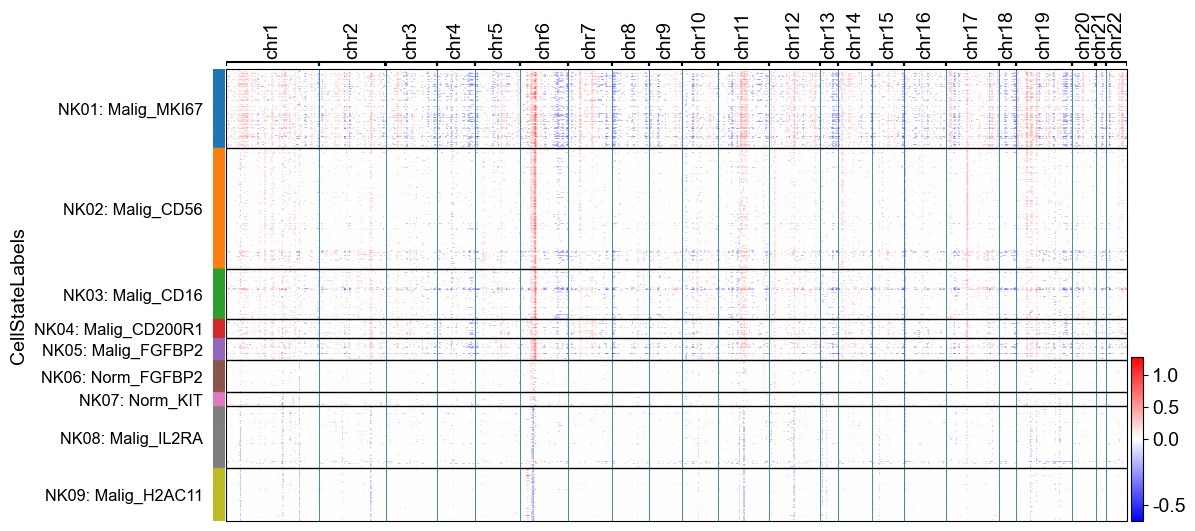

In [ ]:
# ---------------------------------------------------------
# Infer CNV using Normal NK cells as reference
# ---------------------------------------------------------
# This section prepares the data by subsetting the object
# to include only NK cells and assigns 'Normal NK' as the
# reference group. It then runs the inferCNV algorithm to
# calculate copy number variations and visualizes the results
# as a chromosome heatmap grouped by cell state.
# ---------------------------------------------------------
# using the Normal NK to avoid the noise in reference cells
adata_concat_cnv.obs['anno-cnv'] = adata_NK.obs['anno-cnv']
adata_concat_cnv.obs['anno-cnv-minor'] = adata_NK.obs['anno-cnv-minor']
adata_concat_cnv.obs['CellStateLabels'] = adata_NK.obs['CellStateLabels']
adata_concat_cnv1 = adata_concat_cnv[adata_concat_cnv.obs_names.isin(adata_NK.obs_names)].copy()
cnv.tl.infercnv(adata_concat_cnv1,reference_key="anno-cnv", reference_cat=['Normal NK'], layer='Raw', calculate_gene_values=True, n_jobs=32)
ax = cnv.pl.chromosome_heatmap(adata_concat_cnv1, groupby='CellStateLabels', show = False)
fig = ax['heatmap_ax'].get_figure()
fig.set_size_inches(12, 6)
fig.savefig(f"{figPath}/Fig2c.pdf", bbox_inches='tight')
plt.show()

#### **Fig. 2d** The Sankey diagram illustrates the association between treatment states, CNV status, and NK subclusters, with edge width representing the proportions of cells.

In [ ]:
# ---------------------------------------------------------
# Generate Sankey diagram for treatment-cell state flow
# ---------------------------------------------------------
# This section constructs a Sankey diagram to visualize the
# cellular transitions and relationships between treatment
# status, broad cell annotations, and specific NK cell states.
# It aggregates cell counts, filters for significant flows,
# and renders an interactive plot to illustrate the distribution
# of cells across these categories.
# ---------------------------------------------------------
from collections import defaultdict
import plotly.graph_objects as go

df = adata_NK.obs[['treatment',  'anno-standard', 'CellStateLabels',]]

path_counts = defaultdict(int)
for _, row in df.iterrows():
    path = (row["treatment"], row["anno-standard"], row["CellStateLabels"])
    path_counts[path] += 1

all_labels = ['Pre','Post','PBMC','MaligNK_chr6p21Amp', 'MaligNK_chr6p21Del', 'Normal NK', 
              'NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16',
              'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2', 'NK06: Norm_FGFBP2',
              'NK07: Norm_KIT', 'NK08: Malig_IL2RA', 'NK09: Malig_H2AC11']
label_to_index = {label: i for i, label in enumerate(all_labels)}
colors = ['#ffd92f', '#8da0cb', '#66c2a5',"#1f77b4", "#ff7f0e", "#2ca02c", '#66c2a5', '#fc8d62', 
          '#8da0cb', '#e78ac3', '#a6d854', '#a6d854','#ffd92f', '#e5c494', '#b3b3b3']

sources = []
targets = []
values = []

for (label1, label2, label3), count in path_counts.items():
    # from treatment to anno-cnv
    sources.append(label_to_index[label1])
    targets.append(label_to_index[label2])
    values.append(count)
    
    # from anno-cnv to anno-NK
    sources.append(label_to_index[label2])
    targets.append(label_to_index[label3])
    values.append(count)

filtered_links = [(s, t, v) for s, t, v in zip(sources, targets, values) if v >= 15]
filtered_sources = [link[0] for link in filtered_links]
filtered_targets = [link[1] for link in filtered_links]
filtered_values = [link[2] for link in filtered_links]

# sankey plot
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_labels,
        color=colors
    ),
    link=dict(
        source=filtered_sources,
        target=filtered_targets,
        value=filtered_values,
        color=["rgba(0, 128, 0, 0.3)"] * len(sources)
    )
))

fig.update_layout(
    font_size=14,
    height=500,
    width=700,

    xaxis=dict(
        title_text="X Axis",
        title_font=dict(color="black"),
        tickfont=dict(color="black")
    ),
    yaxis=dict(
        title_text="Y Axis",
        title_font=dict(color="black"),
        tickfont=dict(color="black")
    ),

    legend=dict(
        bgcolor="rgba(0,0,0,0)",  # 完全透明背景
        font=dict(color="black")
    ),
)

fig.show()
fig.write_html(f"{figPath}/Fig2d.html")

#### **Fig. 2e** UMAP projection of NK cells colored by proliferation score (calculated from MKI67-related gene signature), with intensity indicating higher proliferative activity.

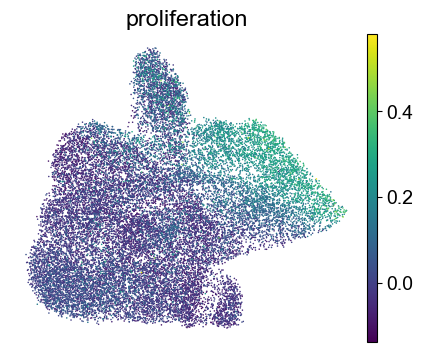

In [736]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sc.pl.umap(adata_NK, color=['proliferation'], size=5, ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/Fig2e.png", dpi=400, bbox_inches='tight')

#### **Fig. 2f** UMAP projection of NK cells colored by LMP-1 expression.

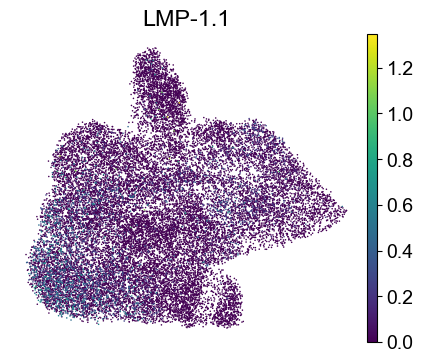

In [737]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sc.pl.umap(adata_NK, color=['LMP-1.1'], size=5, ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/Fig2f.png", dpi=400, bbox_inches='tight')

#### **Fig. 2g** The scatter plot shows the positive correlation (Spearman r=0.555, P=1.42e-101) between LMP-1 and CD274 expression in double-positive cells (n=1246).

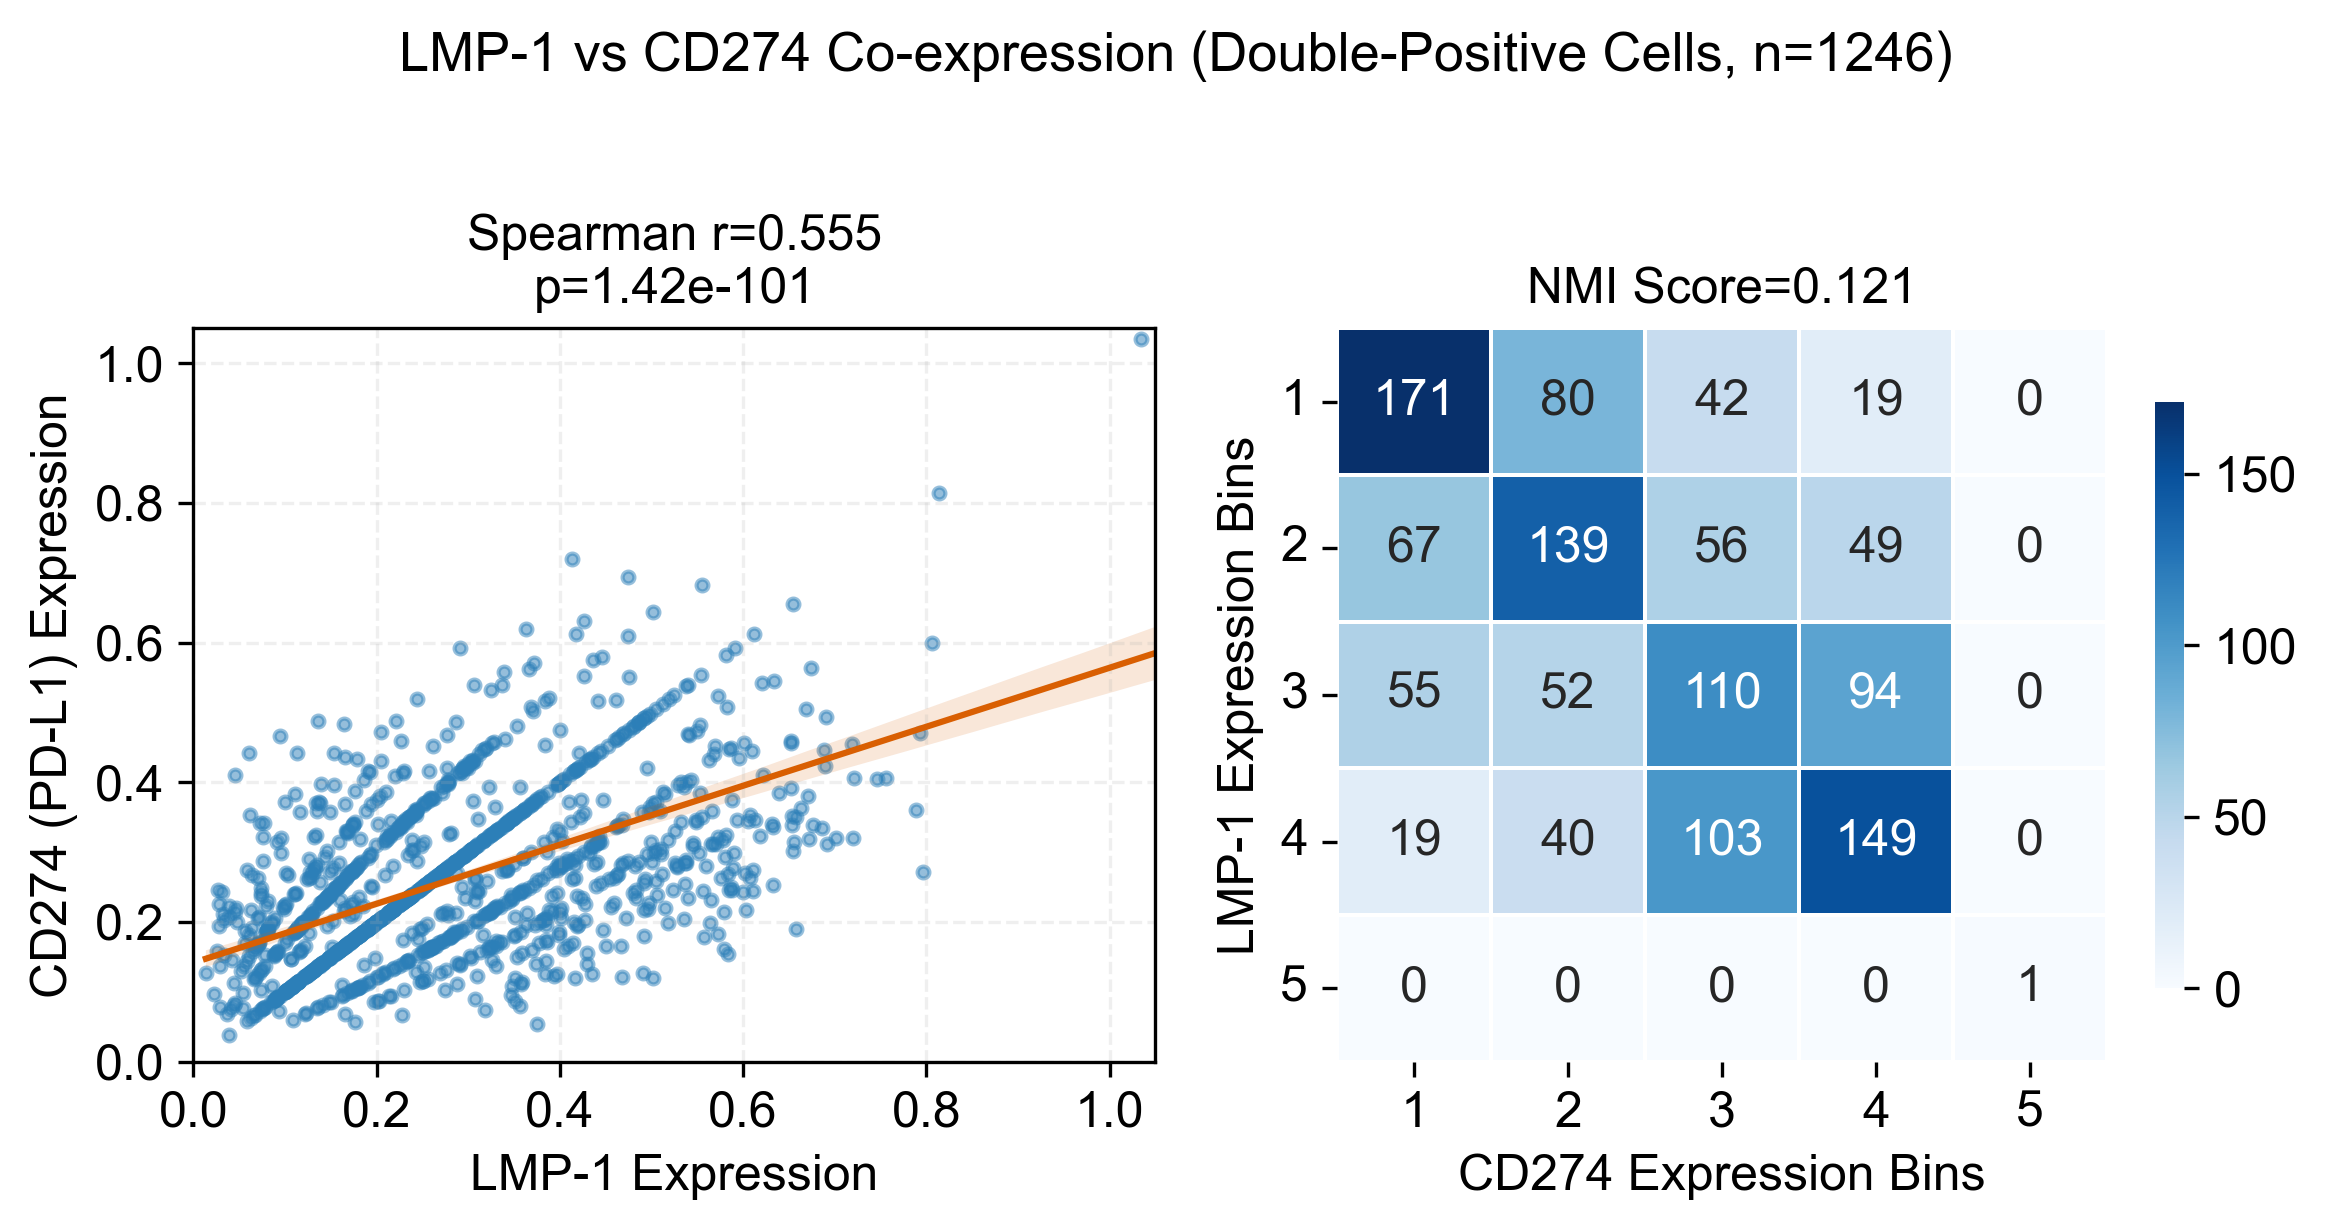

In [ ]:
# ---------------------------------------------------------
# Correlation analysis of LMP-1 and CD274 (PD-L1)
# ---------------------------------------------------------
# This section analyzes the co-expression relationship between 
# LMP-1 and CD274 in double-positive NK cells. It calculates 
# the Spearman correlation coefficient and Normalized Mutual 
# Information (NMI) to quantify both linear dependence and 
# general pattern similarity. Finally, it generates a composite 
# figure containing a scatter plot with a regression line and 
# a heatmap of binned expression values.
# ---------------------------------------------------------
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score
# --------------------------
# 1. Data Preprocessing: Extract double-positive cells
# --------------------------
# Extract expression values (replace with your actual adata_NK)
lmp1_expr = np.array(adata_NK[:, 'LMP-1'].X.todense()).flatten()
cd274_expr = np.array(adata_NK[:, 'CD274'].X.todense()).flatten()

# Keep only cells with both genes expressed (exclude dropout-induced single-positive cells)
double_pos_mask = (lmp1_expr > 0) & (cd274_expr > 0)
lmp1_dp = lmp1_expr[double_pos_mask]
cd274_dp = cd274_expr[double_pos_mask]
n_dp = len(lmp1_dp)  # Number of double-positive cells


# --------------------------
# 2. Calculate Correlation & NMI
# --------------------------
# Spearman correlation (linear trend)
spearman_r, spearman_p = spearmanr(lmp1_dp, cd274_dp)

# Discretize expression for NMI (5 bins, scRNA-seq standard)
def discretize_expr(vec, n_bins=5):
    quantiles = np.quantile(vec, np.linspace(0, 1, n_bins))
    quantiles = np.unique(quantiles)  # Avoid duplicate bins
    return np.digitize(vec, quantiles)

lmp1_bins = discretize_expr(lmp1_dp, n_bins=5)
cd274_bins = discretize_expr(cd274_dp, n_bins=5)

# Normalized Mutual Information (expression pattern dependency)
nmi_score = normalized_mutual_info_score(lmp1_bins, cd274_bins)


# --------------------------
# 3. Plot: 8x4 multi-panel figure (scatter + NMI heatmap)
# --------------------------
plt.rcParams["font.size"] = 12
plt.figure(figsize=(8, 4), dpi=300)  # Set figure size: width=8, height=4

# Subplot 1: Scatter plot (Spearman trend)
plt.subplot(1, 2, 1)
plt.scatter(lmp1_dp, cd274_dp, alpha=0.5, s=8, c='#2c7fb8', rasterized=True)  # Rasterize for small points
# Add Spearman trend line (with 95% confidence interval)
sns.regplot(x=lmp1_dp, y=cd274_dp, scatter=False, color='#d95f02', 
            line_kws={'lw':1.5}, ci=95, ax=plt.gca())
# Annotations
plt.xlabel('LMP-1 Expression')
plt.ylabel('CD274 (PD-L1) Expression')
plt.title(f'Spearman r={spearman_r:.3f}\np={spearman_p:.2e}', fontsize=12)
plt.grid(alpha=0.2, linestyle='--')
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)

# Subplot 2: NMI heatmap (expression bin cross-tab)
plt.subplot(1, 2, 2)
cross_tab = pd.crosstab(lmp1_bins, cd274_bins)
sns.heatmap(cross_tab, cmap='Blues', annot=True, fmt='d', 
            cbar_kws={'shrink': 0.8}, linewidths=0.5, ax=plt.gca())
# Annotations
plt.xlabel('CD274 Expression Bins')
plt.ylabel('LMP-1 Expression Bins')
plt.title(f'NMI Score={nmi_score:.3f}', fontsize=12)
plt.yticks(rotation=0)  # Keep y-labels horizontal

# Adjust layout and save
plt.suptitle(f'LMP-1 vs CD274 Co-expression (Double-Positive Cells, n={n_dp})', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{figPath}/Fig2g.pdf', bbox_inches='tight')  # Save as vector PDF for publication
plt.show()

#### **Fig. 2h** Marker gene expression across NK subtypes. 
Dot plot displaying the average expression of representative marker genes across NK cell clusters. The dot size indicates the percentage of expressing cells; the color represents the expression intensity.

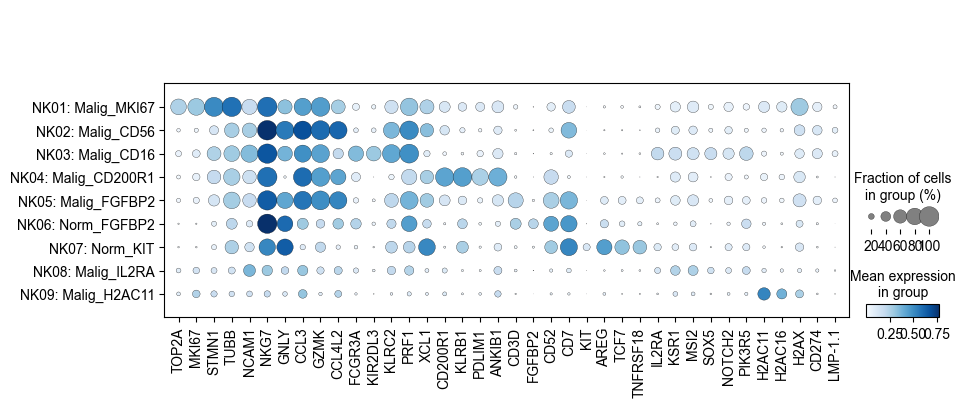

In [739]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sc.pl.dotplot(adata_NK, var_names=[
  'TOP2A', 'MKI67', 'STMN1', 'TUBB',
  'NCAM1', 'NKG7', 'GNLY', 'CCL3', 'GZMK', 'CCL4L2', 
  'FCGR3A','KIR2DL3', 'KLRC2', 'PRF1', 'XCL1',
  "CD200R1", 'KLRB1', 'PDLIM1', 'ANKIB1',
  'CD3D', 'FGFBP2',  'CD52', 'CD7',
  'KIT', 'AREG', 'TCF7', 'TNFRSF18',
  'IL2RA', 'KSR1', 'MSI2', 'SOX5', 'NOTCH2', 'PIK3R5', 
  'H2AC11','H2AC16', 'H2AX','CD274', 'LMP-1.1', 
], groupby='CellStateLabels',cmap='Blues', ax=ax)
fig.savefig(f"{figPath}/Fig2h.svg", bbox_inches='tight')

#### **Fig. 2i** Volcano plot shows EBV-mediated gene regulation in NK cells. 
Genes upregulated in EBV-injected NK cells are highlighted in orange/red, downregulated genes in teal, and non-significant genes in gray.

In [741]:
import memento
import anndata as ad
import pandas as pd

def DE_memento_1d(adata: ad.AnnData, ctleft: list, ctright: list, groupby='annotation'):
  """
  Performs differential expression analysis using the Memento package to detect
  changes in gene expression moments (mean and variance) between two conditions.

  Args:
      adata (ad.AnnData): The AnnData object containing single-cell data. Note that 
                          adata.X (or the layer used) must contain raw count data.
      ctleft (list): A list of cell types or states representing the control/baseline 
                     condition (e.g., Pre-treatment).
      ctright (list): A list of cell types or states representing the stimulated/treated 
                      condition (e.g., Post-treatment).
      groupby (str, optional): The column name in adata.obs used to distinguish the groups. 
                               Defaults to 'annotation'.

  Returns:
      pd.DataFrame: A DataFrame containing the Memento analysis results, including 
                    statistics for differential mean and variance (HT 1D moments).
  """
  _adata = adata[adata.obs[groupby].isin(ctleft + ctright)].copy()
  _adata = ad.AnnData(_adata.layers['Raw'], obs = _adata.obs, var = _adata.var)
  _adata.obs['stim'] = _adata.obs[groupby].isin(ctright)
  _adata.obs['stim'] = _adata.obs['stim'].astype('int')
  _adata.obs['capture_rate'] = 0.07
  memento.setup_memento(_adata, q_column='capture_rate')
  memento.create_groups(_adata, label_columns=['stim'])
  memento.compute_1d_moments(_adata, min_perc_group=.7)
  meta_df = memento.get_groups(_adata)
  meta_df['intercept'] = 1
  convariate = meta_df[['intercept']]
  treatment = (meta_df[['stim']] == 1).astype(float)
  
  memento.ht_1d_moments(_adata,
  covariate=convariate,
  treatment=treatment,
  num_cpus=16,
  resample_rep=False,
  )
  memento_results = memento.get_1d_ht_result(_adata)
  return(memento_results)

In [743]:
# ---------------------------------------------------------
# Differential expression analysis
# ---------------------------------------------------------
# This section defines the specific malignant NK cell subpopulations 
# for the Memento analysis. It sets the 'ctleft' group (representing 
# the LMP-1-) and the 'ctright' group 
# (representing the LMP-1+).
# ---------------------------------------------------------
adata_NK.obs['EBV'] = adata_NK.obs['LMP-1.1'] > 0
adata_NK.obs['EBV'] = adata_NK.obs['EBV'].astype(int)
ctleft = [0]
ctright = [1]
EBV_degs = DE_memento_1d(adata_NK, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='EBV')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    5.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    9.2s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:   14.9s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:   21.4s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:   29.6s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:   38.3s
[Parallel(n_jobs=16)]: Done 3168 tasks      | elapsed:   50.4s
[Parallel(n_jobs=16)]: Done 4018 tasks      | elapsed:  1.0min
[Parallel(n_jobs=16)]: Done 4968 tasks      | elapsed:  1.3min
[Parallel(n_jobs=16)]: Done 6018 tasks      | elapsed:  1.5min
[Parallel(n_jobs=16)]: Done 7168 tasks      | elapsed:  1.8min
[Parallel(n_jobs=16)]: Done 8418 tasks      | elapsed:  2.1min
[Parallel(n_jobs=16)]: Done 8764 out of 8764 | elapsed:  2.2min finished


In [744]:
import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging

In [746]:
# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

In [747]:
%load_ext rpy2.ipython
anndata2ri.set_ipython_converter()

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [755]:
%%R -i EBV_degs
library(ggVolcano)
library(RColorBrewer)
library(ggsci)
data <- add_regulate(EBV_degs, log2FC_name = "de_coef",
                     fdr_name = "de_pval",log2FC = 0.4, fdr = 0.05)
# plot
p <- ggvolcano(data, x = "log2FoldChange", y = "padj",
          label = "gene", label_number = 20, 
          custom_label = c('CD274', 'CDKN1A', 'TNFSF4', 'IFNG', 'TNFSF9', 'DUSP4', 'LTA', 'IL10', 'RGS16', 'GZMB', 'CXCL10', 'EGR2'),
          output = FALSE, legend_position = "UL",
          log2FC_cut = 0.4, FDR_cut = 0.05) +
    labs(x="correlation", y="-log P-value")
ggsave("./figures/fig2/Fig2i.pdf", p, width = 4, height = 4, units = "in")